# 1. 환경 설정

In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import math
import numpy as np

In [2]:
def setup_data():
    org_path = "C:/Users/Owner/Desktop/지윤/3.기타/프로젝트/purchase-conversion-prediction/"
    raw_path = f"{org_path}data/raw/"
    prc_path = f"{org_path}data/processed/"
    seed = 42

    print("변수 세팅 완료")
    return org_path, raw_path, prc_path, seed

# 사용 예시 (반환값 9개)
org_path, raw_path, prc_path, seed = setup_data()

변수 세팅 완료


# 2. 테이블 로드

In [3]:
def load_multiple_csv(base_path: str, filenames: list[str]) -> dict[str, pd.DataFrame]:
    """
    여러 CSV 파일을 한 번에 불러와 DataFrame 딕셔너리로 반환합니다.
    
    Parameters
    ----------
    base_path : str
        기본 경로 (예: "data/raw/")
    filenames : list[str]
        확장자를 제외한 파일명 리스트 (예: ["orders", "products", "users"])

    Returns
    -------
    dict[str, pd.DataFrame]
        각 파일명을 key, DataFrame을 value로 하는 딕셔너리
    """
    base = Path(base_path)
    dataframes = {}

    for name in filenames:
        file_path = base / f"{name}.csv"
        if not file_path.exists():
            print(f"파일 없음: {file_path}")
            continue
        df = pd.read_csv(file_path)
        dataframes[name] = df
        print(f"{name}.csv 로드 완료. shape={df.shape}")

    return dataframes

In [4]:
file_list = [
    "distribution_centers", "events", "inventory_items",
    "order_items", "orders", "products", "users"
]

# CSV 로드
dfs = load_multiple_csv(raw_path, file_list)

distribution_centers.csv 로드 완료. shape=(10, 4)
events.csv 로드 완료. shape=(2431963, 13)
inventory_items.csv 로드 완료. shape=(490705, 12)
order_items.csv 로드 완료. shape=(181759, 11)
orders.csv 로드 완료. shape=(125226, 9)
products.csv 로드 완료. shape=(29120, 9)
users.csv 로드 완료. shape=(100000, 15)


In [5]:
# 변수 자동 생성
for name, df in dfs.items():
    globals()[name] = df
    print(f"변수 생성 완료: {name} (shape={df.shape})")

변수 생성 완료: distribution_centers (shape=(10, 4))
변수 생성 완료: events (shape=(2431963, 13))
변수 생성 완료: inventory_items (shape=(490705, 12))
변수 생성 완료: order_items (shape=(181759, 11))
변수 생성 완료: orders (shape=(125226, 9))
변수 생성 완료: products (shape=(29120, 9))
변수 생성 완료: users (shape=(100000, 15))


# 3. 테이블별 요약 정보 확인

## 3.1 distribution_centers

In [6]:
# 1단계: 자동 추론
distribution_centers =  distribution_centers.convert_dtypes()

# 2단계: 중요한 컬럼만 명시적으로
force_dtypes = {
    'id': 'string'
}
distribution_centers = distribution_centers.astype({k: v for k, v in force_dtypes.items() if k in distribution_centers.columns})

In [7]:
distribution_centers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         10 non-null     string 
 1   name       10 non-null     string 
 2   latitude   10 non-null     Float64
 3   longitude  10 non-null     Float64
dtypes: Float64(2), string(2)
memory usage: 472.0 bytes


In [8]:
distribution_centers.describe(include='all')

,id,name,latitude,longitude
count,10,10,10.0,10.0
unique,10,10,<NA>,<NA>
top,1,Memphis TN,<NA>,<NA>
freq,1,1,<NA>,<NA>
mean,NaN,NaN,34.67931,-87.93855
std,NaN,NaN,4.572666,12.722916
min,NaN,NaN,29.7604,-118.25
25%,NaN,NaN,31.024975,-90.0428
50%,NaN,NaN,33.41665,-87.8639
75%,NaN,NaN,38.74185,-80.22915


In [9]:
distribution_centers

,id,name,latitude,longitude
0,1,Memphis TN,35.1174,-89.9711
1,2,Chicago IL,41.8369,-87.6847
2,3,Houston TX,29.7604,-95.3698
3,4,Los Angeles CA,34.05,-118.25
4,5,New Orleans LA,29.95,-90.0667
5,6,Port Authority of New York/New Jersey NY/NJ,40.634,-73.7834
6,7,Philadelphia PA,39.95,-75.1667
7,8,Mobile AL,30.6944,-88.0431
8,9,Charleston SC,32.7833,-79.9333
9,10,Savannah GA,32.0167,-81.1167


## 3.1 events

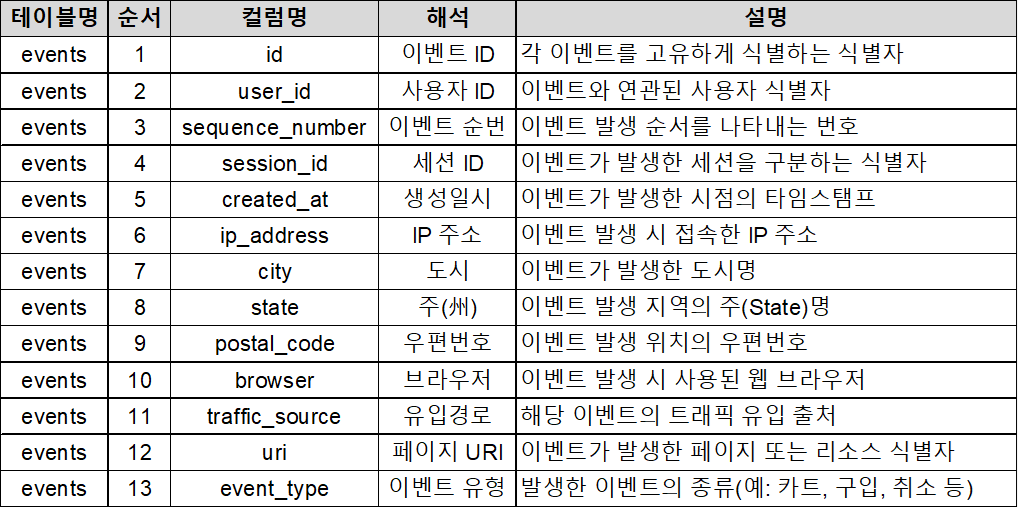

In [10]:
# 데이터 타입 변환
# 1단계: 자동 추론
events =  events.convert_dtypes()

# 2단계: 중요한 컬럼만 명시적으로
# 2단계: 중요한 컬럼만 명시적으로
force_dtypes = {
    'id': 'string',
    'user_id': 'string',
    'sequence_number': 'string',
}

events = events.astype({k: v for k, v in force_dtypes.items() if k in events.columns})

In [11]:
# 1) 컬럼 변수 정의
cat_cols = events.select_dtypes(include=['string', 'category']).columns.tolist()
key_cols = ['id', 'user_id', 'session_id', 'ip_address']
date_cols = ['created_at']
derived_time_cols = ['year', 'month', 'day', 'hour', 'minute', 'second']

# 2) key 컬럼 제외
cat_cols = [col for col in cat_cols if col not in key_cols + date_cols]

# 3) 출력 확인
print("범주형 컬럼:", cat_cols)
print("키 컬럼:", key_cols)
print("시간 컬럼:", date_cols, derived_time_cols)

범주형 컬럼: ['sequence_number', 'city', 'state', 'postal_code', 'browser', 'traffic_source', 'uri', 'event_type']
키 컬럼: ['id', 'user_id', 'session_id', 'ip_address']
시간 컬럼: ['created_at'] ['year', 'month', 'day', 'hour', 'minute', 'second']


파생 변수 생성

In [12]:
# datetime으로 변환
events['created_at'] = pd.to_datetime(events['created_at'], errors='coerce')

# 파생 변수 생성
events['year'] = events['created_at'].dt.year.astype('Int64')
events['month'] = events['created_at'].dt.month.astype('Int64')
events['day'] = events['created_at'].dt.day.astype('Int64')
events['hour'] = events['created_at'].dt.hour.astype('Int64')
events['minute'] = events['created_at'].dt.minute.astype('Int64')
events['second'] = events['created_at'].dt.second.astype('Int64')

# 타입 변환
for c in derived_time_cols:
    events[c] = events[c].astype('Int64').astype('string')

# 사용자 ID 존재 여부 파생 변수 생성
events['is_user_id_present'] = events['user_id'].notna()


# cat_cols에 파생 시간 변수 포함
cat_cols.extend(derived_time_cols+['is_user_id_present'])

In [13]:
# uri 분석을 위한 파생 변수 생성
def extract_first_two_segments(uri):
    segs = uri.split('/')
    return f"/{segs[1]}" if len(segs) >= 2 else uri

events['uri_splt'] = events['uri'].apply(extract_first_two_segments)

# cat_cols에 파생 변수 포함
cat_cols.append('uri_splt')

In [14]:
# 유저별 생성 세션 수 파생 변수 생성
events['unique_session_count'] = (
    events.groupby('user_id')['session_id']
    .transform('nunique')
)

# 한 세션 별 활동 수 파생 변수 생성
events['activity_count'] = events.groupby(['session_id']).transform('size')

### 데이터 전체 구조

In [16]:
events.describe(include='all')

,id,user_id,sequence_number,session_id,created_at,ip_address,city,state,postal_code,browser,...,year,month,day,hour,minute,second,is_user_id_present,uri_splt,unique_session_count,activity_count
count,2431963,1306292,2431963,2431963,2400462,2431963,2408883,2431963,2431963,2431963,...,2400462,2400462,2400462,2400462,2400462,2400462,2431963,2431963,1.306292e+06,2.431963e+06
unique,2431963,80044,13,681759,NaN,681683,8775,231,17324,5,...,6,12,31,24,60,60,2,6,NaN,NaN
top,844526,32996,1,e846b988-9b63-4997-8a85-a4b81318ad0f,NaN,196.46.153.171,Shanghai,Guangdong,02675-031,Chrome,...,2023,12,14,7,16,0,True,/product,NaN,NaN
freq,1,164,681759,13,NaN,17,60561,129796,10147,1218687,...,837211,249070,82526,128811,40479,1146866,1306292,845607,NaN,NaN
mean,NaN,NaN,NaN,NaN,2022-03-11 08:21:42.454857984+00:00,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.817622e+00,5.632292e+00
min,NaN,NaN,NaN,NaN,2019-01-02 00:05:00+00:00,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000e+00,1.000000e+00
25%,NaN,NaN,NaN,NaN,2021-02-05 02:08:15+00:00,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000e+00,3.000000e+00
50%,NaN,NaN,NaN,NaN,2022-06-29 14:02:00+00:00,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.000000e+00,5.000000e+00
75%,NaN,NaN,NaN,NaN,2023-06-15 21:36:10.500000+00:00,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000e+00,7.000000e+00
max,NaN,NaN,NaN,NaN,2024-01-21 16:18:30+00:00,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.400000e+01,1.300000e+01


In [17]:
events.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2431963 entries, 0 to 2431962
Data columns (total 23 columns):
 #   Column                Non-Null Count    Dtype              
---  ------                --------------    -----              
 0   id                    2431963 non-null  string             
 1   user_id               1306292 non-null  string             
 2   sequence_number       2431963 non-null  string             
 3   session_id            2431963 non-null  string             
 4   created_at            2400462 non-null  datetime64[ns, UTC]
 5   ip_address            2431963 non-null  string             
 6   city                  2408883 non-null  string             
 7   state                 2431963 non-null  string             
 8   postal_code           2431963 non-null  string             
 9   browser               2431963 non-null  string             
 10  traffic_source        2431963 non-null  string             
 11  uri                   2431963 non-nul

In [18]:
events.head()

,id,user_id,sequence_number,session_id,created_at,ip_address,city,state,postal_code,browser,...,year,month,day,hour,minute,second,is_user_id_present,uri_splt,unique_session_count,activity_count
0,2198523,<NA>,3,83889ed2-2adc-4b9a-af5d-154f6998e778,2021-06-17 17:30:00+00:00,138.143.9.202,São Paulo,São Paulo,02675-031,Chrome,...,2021,6,17,17,30,0,False,/cancel,NaN,3
1,1773216,<NA>,3,7a3fc3f2-e84f-44fe-8876-eff76741f7a3,2020-08-07 08:41:00+00:00,85.114.141.79,Santa Isabel,São Paulo,07500-000,Safari,...,2020,8,7,8,41,0,False,/cancel,NaN,3
2,2380515,<NA>,3,13d9b2fb-eee1-43fd-965c-267b38dd7125,2021-02-15 18:48:00+00:00,169.250.255.132,Mairiporã,São Paulo,07600-000,IE,...,2021,2,15,18,48,0,False,/cancel,NaN,3
3,2250597,<NA>,3,96f1d44e-9621-463c-954c-d8deb7fffe7f,2022-03-30 10:56:00+00:00,137.25.222.160,Cajamar,São Paulo,07750-000,Chrome,...,2022,3,30,10,56,0,False,/cancel,NaN,3
4,1834446,<NA>,3,d09dce10-a7cb-47d3-a9af-44975566fa03,2019-09-05 01:18:00+00:00,161.114.4.174,São Paulo,São Paulo,09581-680,Chrome,...,2019,9,5,1,18,0,False,/cancel,NaN,3


### 주요 변수 분포 및 특성 분석

**범주형 변수 분포**

In [19]:
def plot_categorical_overview(
    df,
    cols,
    per_row=3,
    rotate=45,
    per_ax_size=(5, 3.5),
    na_label="NA",
    top_k=60,          # 기본 top_k
    topk_map=None,     # 특정 컬럼만 다른 top_k
    exclude_cols=None  # ⭐ 특정 컬럼 제외
):
    # ------------------------------
    # 0) 제외 컬럼 처리
    # ------------------------------
    exclude_cols = exclude_cols or []
    cols = [c for c in cols if c not in exclude_cols]

    n = len(cols)
    if n == 0:
        print("No categorical columns to plot after excluding.")
        return

    # ------------------------------
    # 1) subplot 설정
    # ------------------------------
    nrows = math.ceil(n / per_row)
    figsize = (per_ax_size[0] * per_row, per_ax_size[1] * nrows)
    fig, axes = plt.subplots(nrows, per_row, figsize=figsize)
    axes = np.array(axes).reshape(-1)

    topk_map = topk_map or {}

    # ------------------------------
    # 2) 컬럼별 시각화
    # ------------------------------
    for i, col in enumerate(cols):
        ax = axes[i]

        # 결측 치환
        s = df[col].fillna(na_label)

        # 빈도 집계
        vc = s.value_counts(dropna=False)
        if vc.empty:
            ax.set_title(f"{col}\n(모든 값 결측)")
            ax.axis("off")
            continue

        # 값 기준 정렬
        vc = vc.sort_index()

        # 개별 top_k 적용 여부
        k = topk_map.get(col, top_k)
        if k is not None:
            vc = vc.head(k)

        counts = vc.values
        labels = vc.index.astype(str)
        x = np.arange(len(vc))

        # 막대그래프
        ax.bar(x, counts)

        # 평균선
        mean_cnt = counts.mean()
        ax.axhline(mean_cnt, linestyle="--", linewidth=1,
                   label=f"mean={mean_cnt:.0f}")

        # x축 설정
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=rotate)

        # 통계 정보
        uniq = df[col].nunique(dropna=False)
        uniq_fmt = f"{uniq:,}"

        total = vc.sum()
        top1_share = vc.iloc[0] / total if total > 0 else 0
        top5_share = vc.head(5).sum() / total if total > 0 else 0

        ax.set_title(col, fontsize=10)
        ax.set_ylabel("Count")
        ax.legend(fontsize=8, loc="upper right")

        # 각주
        ax.text(
            1.02, 0.5,
            f"uniq={uniq_fmt}\ntop1={top1_share:.1%}\ntop5={top5_share:.1%}",
            transform=ax.transAxes,
            va="center",
            fontsize=8
        )

    # 남은 subplot 삭제
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.4, wspace=0.3)
    plt.show()

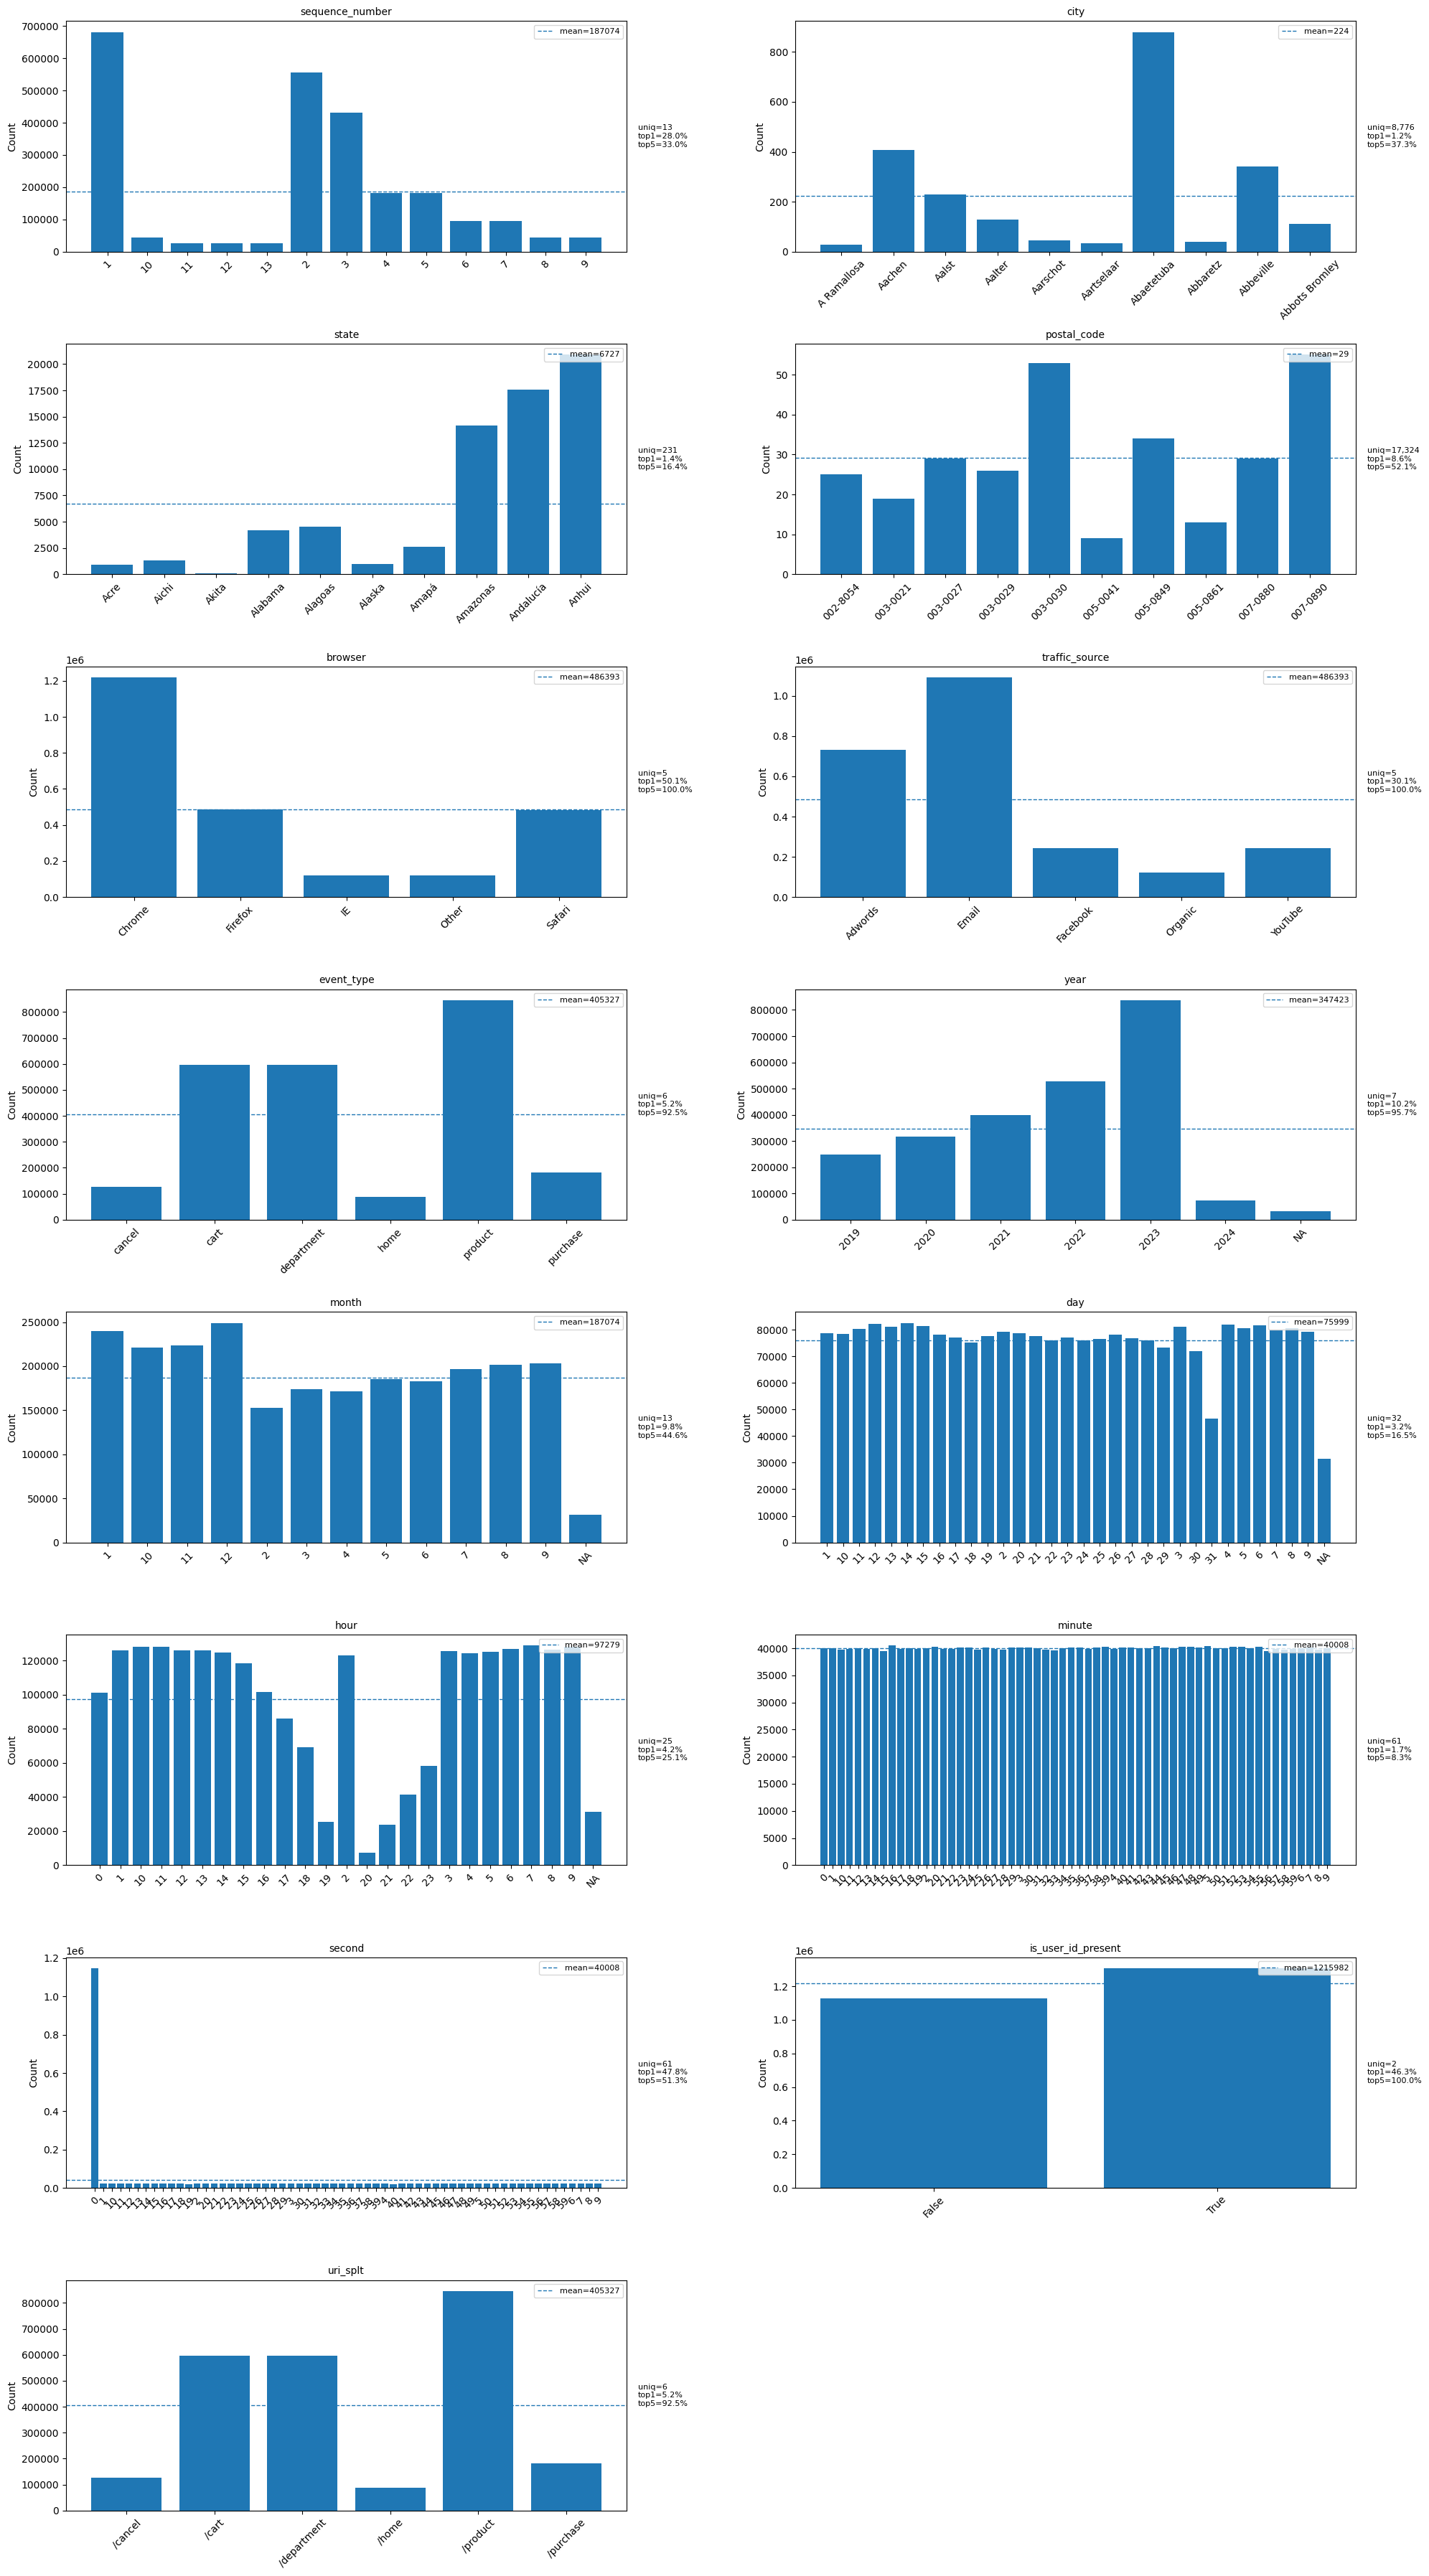

In [20]:
# 컬럼별 개별 top_k 설정
special_topk = {
    "city": 10,         # city: 상위 10개까지만 표시
    "state": 10,        # state: 상위 10개까지만 표시
    "postal_code": 10,  # postal_code: 상위 10개까지만 표시
}
# 제외 컬럼 설정
exclude_cols = ["uri"]

plot_categorical_overview(
    events,
    cols=cat_cols,
    per_row=2,
    rotate=45,
    per_ax_size=(10, 4.5),
    na_label="NA",
    top_k=60,
    topk_map=special_topk,
    exclude_cols=exclude_cols,
)

In [21]:
for col in cat_cols:
    print(f"=== {col} ===")
    vals = events[col].value_counts(dropna=False, normalize=True)
    print(vals.head(10).round(3))  # 소수점 2자리까지 반올림

=== sequence_number ===
sequence_number
1      0.28
2     0.229
3     0.178
5     0.075
4     0.075
7     0.039
6     0.039
9     0.018
10    0.018
8     0.018
Name: proportion, dtype: Float64
=== city ===
city
Shanghai    0.025
Beijing     0.022
Seoul       0.015
Shenzhen    0.013
<NA>        0.009
Dongguan    0.009
Chengdu     0.009
New York    0.008
Tokyo       0.008
Wuhan       0.008
Name: proportion, dtype: Float64
=== state ===
state
Guangdong     0.053
England       0.041
California    0.037
Shanghai      0.024
Texas         0.024
Zhejiang      0.022
Beijing       0.022
São Paulo     0.021
Hebei         0.021
Jiangsu       0.019
Name: proportion, dtype: Float64
=== postal_code ===
postal_code
02675-031    0.004
70297-400    0.004
40301-110    0.003
40301-155    0.002
361006       0.001
81020-490    0.001
59           0.001
25265-008    0.001
65137-000    0.001
66           0.001
Name: proportion, dtype: Float64
=== browser ===
browser
Chrome     0.501
Firefox      0.2
Safari    

변수별 특징 확인

In [22]:
# 세션 단위 user_id 중복 여부 집계
counts_dup = (
    events.groupby('session_id')['is_user_id_present']
          .nunique()
          .value_counts()
)
print("세션별 user_id 중복 여부 요약:\n", counts_dup.apply(lambda x: f"{x:,}"), "\n")
# 중복 없음 

# 세션 단위 user_id 존재 여부 집계
counts_no_dup = (
    events.groupby('session_id')['is_user_id_present']
          .first()
          .value_counts()
)
print("세션별 user_id 포함 여부 요약:\n", counts_no_dup.apply(lambda x: f"{x:,}"), "\n")

# user_id의 고유 값 개수 산출
print(f"user_id 고유 개수: {events['user_id'].nunique(dropna=True):,}")

# user_id 기준 세션 생성 수 집계
sessions_per_user = (
    events[['user_id', 'session_id']]
    .drop_duplicates()               # 동일 user_id 내 중복 세션 제거
    .groupby('user_id')['session_id']
    .nunique()                       # user_id별 세션 수 계산
)

print(f"\n전체 user_id 수: {sessions_per_user.shape[0]:,}")
print("user_id 기준 세션 생성 수 요약:")    
print(sessions_per_user.reset_index(name='session_count')['session_count'].describe().apply(lambda x: f"{x:,}"))

# 반 정도는 1회 구입후 재구매 진행 없음. 단, 반이상은 다빈도로 재구매 진행함

세션별 user_id 중복 여부 요약:
 is_user_id_present
1    681,759
Name: count, dtype: object 

세션별 user_id 포함 여부 요약:
 is_user_id_present
False    500,000
True     181,759
Name: count, dtype: object 

user_id 고유 개수: 80,044

전체 user_id 수: 80,044
user_id 기준 세션 생성 수 요약:
count             80,044.0
mean     2.270738593773425
std      1.606249055972696
min                    1.0
25%                    1.0
50%                    2.0
75%                    3.0
max                   14.0
Name: session_count, dtype: object


In [23]:
sessions_per_user.reset_index(name='session_count')

,user_id,session_count
0,1,3
1,100,1
2,1000,1
3,10000,1
4,100000,2
...,...,...
80039,99992,3
80040,99993,1
80041,99996,4
80042,99998,3


In [24]:
print(f"Shape: {events.shape}")  # 데이터 행, 열 출력
print(f"Unique id count: {events['id'].nunique()}")  # id 컬럼의 고유값 개수
print(f"Min id: {events['id'].min()}, Max id: {events['id'].max()}")  # id 컬럼 최소/최대값

Shape: (2431963, 23)
Unique id count: 2431963
Min id: 1, Max id: 999999


In [25]:
events.sort_values(by='id', key=lambda x: x.astype(int)).head(10)

,id,user_id,sequence_number,session_id,created_at,ip_address,city,state,postal_code,browser,...,year,month,day,hour,minute,second,is_user_id_present,uri_splt,unique_session_count,activity_count
1822544,1,1,1,bccf01cb-6f3b-4ef7-aaff-0ea67e584334,2022-07-18 10:17:52+00:00,59.203.14.177,Bucheon City,Gyeonggi-do,421-150,Firefox,...,2022,7,18,10,17,52,True,/department,3.0,10
1731193,2,1,2,bccf01cb-6f3b-4ef7-aaff-0ea67e584334,2022-07-18 10:18:43+00:00,59.203.14.177,Bucheon City,Gyeonggi-do,421-150,Firefox,...,2022,7,18,10,18,43,True,/product,3.0,10
1270511,3,1,3,bccf01cb-6f3b-4ef7-aaff-0ea67e584334,2022-07-18 10:21:38+00:00,59.203.14.177,Bucheon City,Gyeonggi-do,421-150,Firefox,...,2022,7,18,10,21,38,True,/cart,3.0,10
1375939,4,1,4,bccf01cb-6f3b-4ef7-aaff-0ea67e584334,2022-07-18 10:21:42+00:00,59.203.14.177,Bucheon City,Gyeonggi-do,421-150,Firefox,...,2022,7,18,10,21,42,True,/department,3.0,10
1880043,5,1,5,bccf01cb-6f3b-4ef7-aaff-0ea67e584334,2022-07-18 10:21:53+00:00,59.203.14.177,Bucheon City,Gyeonggi-do,421-150,Firefox,...,2022,7,18,10,21,53,True,/product,3.0,10
1171363,6,1,6,bccf01cb-6f3b-4ef7-aaff-0ea67e584334,2022-07-18 10:22:53+00:00,59.203.14.177,Bucheon City,Gyeonggi-do,421-150,Firefox,...,2022,7,18,10,22,53,True,/cart,3.0,10
2194159,7,1,7,bccf01cb-6f3b-4ef7-aaff-0ea67e584334,2022-07-18 10:25:11+00:00,59.203.14.177,Bucheon City,Gyeonggi-do,421-150,Firefox,...,2022,7,18,10,25,11,True,/department,3.0,10
887742,8,1,8,bccf01cb-6f3b-4ef7-aaff-0ea67e584334,2022-07-18 10:27:56+00:00,59.203.14.177,Bucheon City,Gyeonggi-do,421-150,Firefox,...,2022,7,18,10,27,56,True,/product,3.0,10
1022646,9,1,9,bccf01cb-6f3b-4ef7-aaff-0ea67e584334,2022-07-18 10:29:16+00:00,59.203.14.177,Bucheon City,Gyeonggi-do,421-150,Firefox,...,2022,7,18,10,29,16,True,/cart,3.0,10
1166366,10,1,10,bccf01cb-6f3b-4ef7-aaff-0ea67e584334,2022-07-20 10:32:05+00:00,59.203.14.177,Bucheon City,Gyeonggi-do,421-150,Firefox,...,2022,7,20,10,32,5,True,/purchase,3.0,10


In [26]:
# 'session_id'별로 그룹화 후 집계 수행
# - 'purchase_count': 각 세션에서 event_type이 'purchase'인 횟수 계산
# - 'unique_ip_count': 각 세션에서 유니크한 'ip_address' 개수 계산
# 세션별 실질적인 구매 이벤트 빈도와 접속 IP 다양성을 파악합니다.
# 이는 세션 생성 기준을 이해하고, 사용자 행동 분석 및 이상 탐지에 활용할 수 있습니다.
result = events.groupby('session_id').agg(
    purchase_count = ('event_type', lambda x: (x == 'purchase').sum()),
    unique_ip_count = ('ip_address', 'nunique')
).reset_index()

# 집계 결과 출력
print(result)

                                  session_id  purchase_count  unique_ip_count
0       00000763-a855-4ad0-a95c-b160e749b272               0                1
1       0000364a-ce41-46f1-89d6-3f8704af77db               1                1
2       00004b15-f2d4-4687-b4c1-fc9ce336d39a               0                1
3       00004cf0-0d54-4347-8b0c-dccc700a2c96               0                1
4       00004e02-6372-47a6-aaf7-f231de654979               1                1
...                                      ...             ...              ...
681754  ffff7645-26f7-410f-8498-0c601d74c67a               0                1
681755  ffff8086-da2c-4045-94ba-453437cd3289               0                1
681756  ffffa9aa-4345-4c2a-b389-8fd58844472e               0                1
681757  ffffc3b7-9bc3-44d0-935e-cfaf11c91a0e               0                1
681758  ffffc96a-b665-41a1-8a9a-1101c46e6620               1                1

[681759 rows x 3 columns]


In [27]:
# 한 세션 당 동일 ip임
print(result['unique_ip_count'].value_counts())

# 구입 전환되면 세션이 종료되는 듯함
print(result['purchase_count'].value_counts())

# purchase_count가 1인 애들 대상으로 마지막이 purchase인지 확인 필요

unique_ip_count
1    681759
Name: count, dtype: int64
purchase_count
0    500000
1    181759
Name: count, dtype: int64


In [28]:
# purchase_count가 1인 세션에서 마지막 이벤트의 종류 확인
# 결과를 통해 purchase_count가 1인 세션들은 마지막 이벤트가 모두 'purchase'임을 확인

# purchase_count가 1인 세션만 필터링하여 해당 세션 목록 생성
purchase_sessions = result[result['purchase_count'] == 1]['session_id']

# 필터링된 세션에 속하는 이벤트만 선택
filtered_events = events[events['session_id'].isin(purchase_sessions)]

# 올바른 비교를 위해 'sequence_number'를 정수형으로 변환
filtered_events['sequence_number'] = filtered_events['sequence_number'].astype(int)

# 각 세션별로 가장 큰 sequence_number 값을 가지는 행의 인덱스 추출 (즉, 마지막 이벤트)
idx = filtered_events.groupby('session_id')['sequence_number'].idxmax()

# 최대 sequence_number를 가진 이벤트 행 선택하여 session_id와 event_type 확인
last_events = filtered_events.loc[idx, ['session_id', 'event_type']]

# 마지막 이벤트 타입별 빈도 출력
print(last_events['event_type'].value_counts())

C:\Users\Owner\AppData\Local\Temp\ipykernel_25968\1947097508.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_events['sequence_number'] = filtered_events['sequence_number'].astype(int)


event_type
purchase    181759
Name: count, dtype: Int64


In [29]:
# purchase_count가 0인 세션에서 마지막 이벤트의 종류 확인
# 결과를 통해 purchase_count가 0인 세션들은 마지막 이벤트가 모두 'purchase'임을 확인

# purchase_count가 0인 세션만 필터링하여 해당 세션 목록 생성
purchase_sessions = result[result['purchase_count'] == 0]['session_id']

# 필터링된 세션에 속하는 이벤트만 선택
filtered_events = events[events['session_id'].isin(purchase_sessions)]

# 올바른 비교를 위해 'sequence_number'를 정수형으로 변환
filtered_events['sequence_number'] = filtered_events['sequence_number'].astype(int)

# 각 세션별로 가장 큰 sequence_number 값을 가지는 행의 인덱스 추출 (즉, 마지막 이벤트)
idx = filtered_events.groupby('session_id')['sequence_number'].idxmax()

# 최대 sequence_number를 가진 이벤트 행 선택하여 session_id와 event_type 확인
last_events = filtered_events.loc[idx, ['session_id', 'event_type']]

# 마지막 이벤트 타입별 빈도 출력
print(last_events['event_type'].value_counts())

C:\Users\Owner\AppData\Local\Temp\ipykernel_25968\3909245006.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_events['sequence_number'] = filtered_events['sequence_number'].astype(int)


event_type
product    249613
cancel     125568
cart       124819
Name: count, dtype: Int64


In [30]:
# event_type이 cancel인 세션만 필터링하여 해당 세션 목록 생성
purchase_sessions = last_events[last_events['event_type'] == 'cancel']['session_id']

# 필터링된 세션에 속하는 이벤트만 선택
filtered_events = events[events['session_id'].isin(purchase_sessions)]

print(f"===== 전체 event_type ===== \n{events['event_type'].value_counts()}")
print(f"===== purchase_count가 0이면서 event_type이 cancel인 경우 ===== \n {len(purchase_sessions)}")
print(f"===== event_type이 cancel인 경우, user_id ===== \n {filtered_events['user_id'].value_counts(dropna=False)}")
print(f"===== 전체 user_id가 null인 경우 ===== \n {events['user_id'].isna().sum()}")

# user_id가 없는 세션에서 구입 전환 이루어 지지 않을 경우 cancel로 마무리
print(filtered_events.sort_values(by='id', key=lambda x: x.astype(int)).head(10))

===== 전체 event_type ===== 
event_type
product       845607
cart          595994
department    595323
purchase      181759
cancel        125568
home           87712
Name: count, dtype: Int64
===== purchase_count가 0이면서 event_type이 cancel인 경우 ===== 
 125568
===== event_type이 cancel인 경우, user_id ===== 
 user_id
<NA>    376704
Name: count, dtype: Int64
===== 전체 user_id가 null인 경우 ===== 
 1125671
              id user_id sequence_number  \
2153889  1306294    <NA>               1   
1668137  1306295    <NA>               2   
1639293  1306296    <NA>               3   
2378967  1306300    <NA>               1   
801075   1306301    <NA>               2   
671582   1306302    <NA>               3   
2176217  1306325    <NA>               1   
946860   1306326    <NA>               2   
845228   1306327    <NA>               3   
2424617  1306328    <NA>               1   

                                   session_id                created_at  \
2153889  cd086aa9-7110-4d10-a57c-d6c54a26cc38 2

In [31]:
# user_id가 있는 세션에서 마무리 유형 확인 -- purchase만 존재
# user_id가 있는 세션만 필터링하여 해당 세션 목록 생성
purchase_sessions = events[events['user_id'].notna()]['session_id']

# 필터링된 세션에 속하는 이벤트만 선택
filtered_events = events[events['session_id'].isin(purchase_sessions)]

# 올바른 비교를 위해 'sequence_number'를 정수형으로 변환
filtered_events['sequence_number'] = filtered_events['sequence_number'].astype(int)

# 각 세션별로 가장 큰 sequence_number 값을 가지는 행의 인덱스 추출 (즉, 마지막 이벤트)
idx = filtered_events.groupby('session_id')['sequence_number'].idxmax()

# 최대 sequence_number를 가진 이벤트 행 선택하여 session_id와 event_type 확인
last_events = filtered_events.loc[idx, ['session_id', 'event_type']]

# 마지막 이벤트 타입별 빈도 출력
print('events user_id 존재: ', events['user_id'].notna().sum())
print(last_events['event_type'].value_counts())

C:\Users\Owner\AppData\Local\Temp\ipykernel_25968\3592561170.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_events['sequence_number'] = filtered_events['sequence_number'].astype(int)


events user_id 존재:  1306292
event_type
purchase    181759
Name: count, dtype: Int64


In [32]:
# user_id가 없는 세션에서 마무리 유형 확인
# user_id가 없는 세션만 필터링하여 해당 세션 목록 생성
purchase_sessions =  events[events['user_id'].isna()]['session_id']

# 필터링된 세션에 속하는 이벤트만 선택
filtered_events = events[events['session_id'].isin(purchase_sessions)]

# 올바른 비교를 위해 'sequence_number'를 정수형으로 변환
filtered_events['sequence_number'] = filtered_events['sequence_number'].astype(int)

# 각 세션별로 가장 큰 sequence_number 값을 가지는 행의 인덱스 추출 (즉, 마지막 이벤트)
idx = filtered_events.groupby('session_id')['sequence_number'].idxmax()

# 최대 sequence_number를 가진 이벤트 행 선택하여 session_id와 event_type 확인
last_events = filtered_events.loc[idx, ['session_id', 'event_type']]

# 마지막 이벤트 타입별 빈도 출력
print('events user_id 미존재: ', events['user_id'].isna().sum())
print(last_events['event_type'].value_counts())

C:\Users\Owner\AppData\Local\Temp\ipykernel_25968\2840760198.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_events['sequence_number'] = filtered_events['sequence_number'].astype(int)


events user_id 미존재:  1125671
event_type
product    249613
cancel     125568
cart       124819
Name: count, dtype: Int64


In [33]:
filtered_events = events[events['user_id'].isna()]
filtered_events['sequence_number'] = filtered_events['sequence_number'].astype(int)

filtered_events.sort_values(by=['ip_address', 'session_id', 'sequence_number']).head(40)

C:\Users\Owner\AppData\Local\Temp\ipykernel_25968\2364593626.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_events['sequence_number'] = filtered_events['sequence_number'].astype(int)


,id,user_id,sequence_number,session_id,created_at,ip_address,city,state,postal_code,browser,...,year,month,day,hour,minute,second,is_user_id_present,uri_splt,unique_session_count,activity_count
1128524,1342384,<NA>,1,c8313944-da56-454f-94dc-64a8c6c6e164,2020-01-20 16:04:00+00:00,1.0.13.232,Chongqing,Guangdong,515157,Chrome,...,2020,1,20,16,4,0,False,/department,NaN,2
2203204,1342385,<NA>,2,c8313944-da56-454f-94dc-64a8c6c6e164,2020-01-20 16:26:00+00:00,1.0.13.232,Chongqing,Guangdong,515157,Chrome,...,2020,1,20,16,26,0,False,/product,NaN,2
1671047,2428906,<NA>,1,17cf3aa9-3a1b-4cdb-a942-f0ade52c6be0,2022-05-19 10:23:00+00:00,1.0.172.120,Vinhedo,São Paulo,13280-000,Firefox,...,2022,5,19,10,23,0,False,/department,NaN,2
1380854,2428907,<NA>,2,17cf3aa9-3a1b-4cdb-a942-f0ade52c6be0,2022-05-19 10:34:00+00:00,1.0.172.120,Vinhedo,São Paulo,13280-000,Firefox,...,2022,5,19,10,34,0,False,/product,NaN,2
1796634,2166972,<NA>,1,6fdbd366-02bb-4877-934c-20fed98aeefe,2022-02-20 12:54:00+00:00,1.0.173.35,Görlitz,Sachsen,2827,Firefox,...,2022,2,20,12,54,0,False,/department,NaN,2
2076739,2166973,<NA>,2,6fdbd366-02bb-4877-934c-20fed98aeefe,2022-02-20 12:54:00+00:00,1.0.173.35,Görlitz,Sachsen,2827,Firefox,...,2022,2,20,12,54,0,False,/product,NaN,2
1547225,2049448,<NA>,1,31c47935-d272-4101-9199-f092d0ed9902,2021-02-26 04:48:00+00:00,1.0.204.199,Monroeville,Pennsylvania,15146,Firefox,...,2021,2,26,4,48,0,False,/department,NaN,2
884928,2049449,<NA>,2,31c47935-d272-4101-9199-f092d0ed9902,2021-02-26 05:02:00+00:00,1.0.204.199,Monroeville,Pennsylvania,15146,Firefox,...,2021,2,26,5,2,0,False,/product,NaN,2
1132425,1539952,<NA>,1,008c9596-d6ee-4ec1-8f3e-8bc989869606,2021-01-23 10:17:00+00:00,1.0.217.0,Amherst,Massachusetts,1002,Chrome,...,2021,1,23,10,17,0,False,/product,NaN,3
26314,1539953,<NA>,2,008c9596-d6ee-4ec1-8f3e-8bc989869606,2021-01-23 10:46:00+00:00,1.0.217.0,Amherst,Massachusetts,1002,Chrome,...,2021,1,23,10,46,0,False,/cart,NaN,3


In [34]:
events['event_type'].value_counts()

event_type
product       845607
cart          595994
department    595323
purchase      181759
cancel        125568
home           87712
Name: count, dtype: Int64

### 집계

In [35]:
events.head()

,id,user_id,sequence_number,session_id,created_at,ip_address,city,state,postal_code,browser,...,year,month,day,hour,minute,second,is_user_id_present,uri_splt,unique_session_count,activity_count
0,2198523,<NA>,3,83889ed2-2adc-4b9a-af5d-154f6998e778,2021-06-17 17:30:00+00:00,138.143.9.202,São Paulo,São Paulo,02675-031,Chrome,...,2021,6,17,17,30,0,False,/cancel,NaN,3
1,1773216,<NA>,3,7a3fc3f2-e84f-44fe-8876-eff76741f7a3,2020-08-07 08:41:00+00:00,85.114.141.79,Santa Isabel,São Paulo,07500-000,Safari,...,2020,8,7,8,41,0,False,/cancel,NaN,3
2,2380515,<NA>,3,13d9b2fb-eee1-43fd-965c-267b38dd7125,2021-02-15 18:48:00+00:00,169.250.255.132,Mairiporã,São Paulo,07600-000,IE,...,2021,2,15,18,48,0,False,/cancel,NaN,3
3,2250597,<NA>,3,96f1d44e-9621-463c-954c-d8deb7fffe7f,2022-03-30 10:56:00+00:00,137.25.222.160,Cajamar,São Paulo,07750-000,Chrome,...,2022,3,30,10,56,0,False,/cancel,NaN,3
4,1834446,<NA>,3,d09dce10-a7cb-47d3-a9af-44975566fa03,2019-09-05 01:18:00+00:00,161.114.4.174,São Paulo,São Paulo,09581-680,Chrome,...,2019,9,5,1,18,0,False,/cancel,NaN,3


In [36]:
events.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2431963 entries, 0 to 2431962
Data columns (total 23 columns):
 #   Column                Non-Null Count    Dtype              
---  ------                --------------    -----              
 0   id                    2431963 non-null  string             
 1   user_id               1306292 non-null  string             
 2   sequence_number       2431963 non-null  string             
 3   session_id            2431963 non-null  string             
 4   created_at            2400462 non-null  datetime64[ns, UTC]
 5   ip_address            2431963 non-null  string             
 6   city                  2408883 non-null  string             
 7   state                 2431963 non-null  string             
 8   postal_code           2431963 non-null  string             
 9   browser               2431963 non-null  string             
 10  traffic_source        2431963 non-null  string             
 11  uri                   2431963 non-nul

    year month   count
59  2019     1   18059
60  2019     2   17594
58  2019     3   19801
57  2019     4   19846
55  2019     5   20663
..   ...   ...     ...
3   2023     9   75061
2   2023    10   83393
1   2023    11   89113
0   2023    12  106248
4   2024     1   73447

[61 rows x 3 columns]


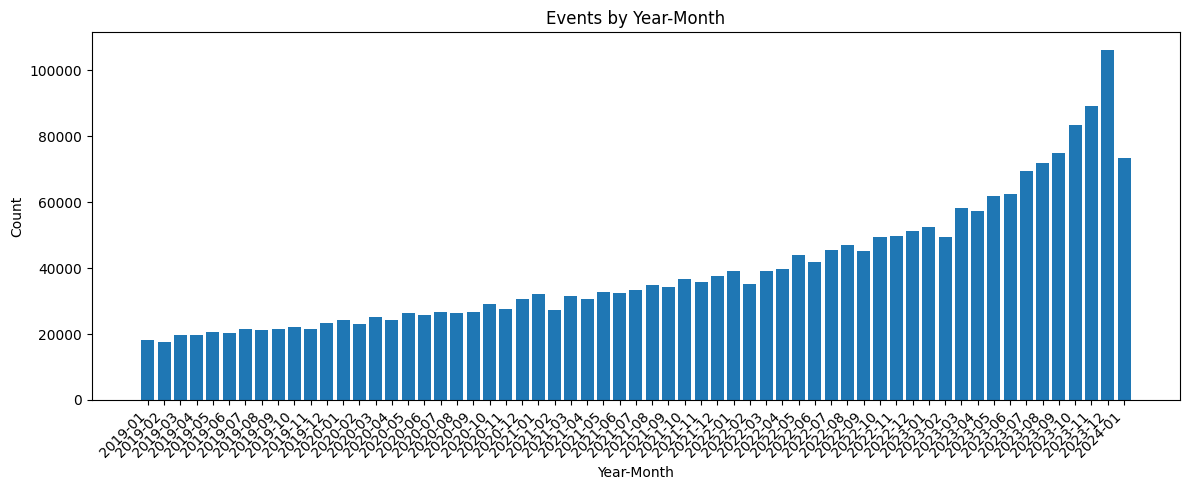

In [37]:
df = events[['year','month']].value_counts().reset_index().sort_values(by=['year','month'], key=lambda x: x.astype(int))
print(df)

df['year_month'] = df['year'].astype(str) + '-' + df['month'].astype(str).str.zfill(2)

plt.figure(figsize=(12, 5))
plt.bar(df['year_month'], df['count'])
plt.xticks(rotation=45, ha='right')
plt.xlabel("Year-Month")
plt.ylabel("Count")
plt.title("Events by Year-Month")
plt.tight_layout()
plt.show()

# 2019년 12월 : 중국 우한에서 원인불명의 폐렴 보고
# 2020년 1월 30일 : WHO, 국제적 공중보건 비상사태(PHEIC) 선언
# 2020년 3월 11일 ~ 2023년 5월 5일: 코로나 팬데믹 기간

   hour   count
16    0  101236
8     1  126131
13    2  123025
9     3  125427
12    4  124463
10    5  125270
4     6  126837
0     7  128811
5     8  126461
3     9  127939
1    10  128024
2    11  127994
6    12  126241
7    13  126221
11   14  124906
14   15  118308
15   16  101787
17   17   86095
18   18   69404
21   19   25205
23   20    7295
22   21   23647
20   22   41445
19   23   58290


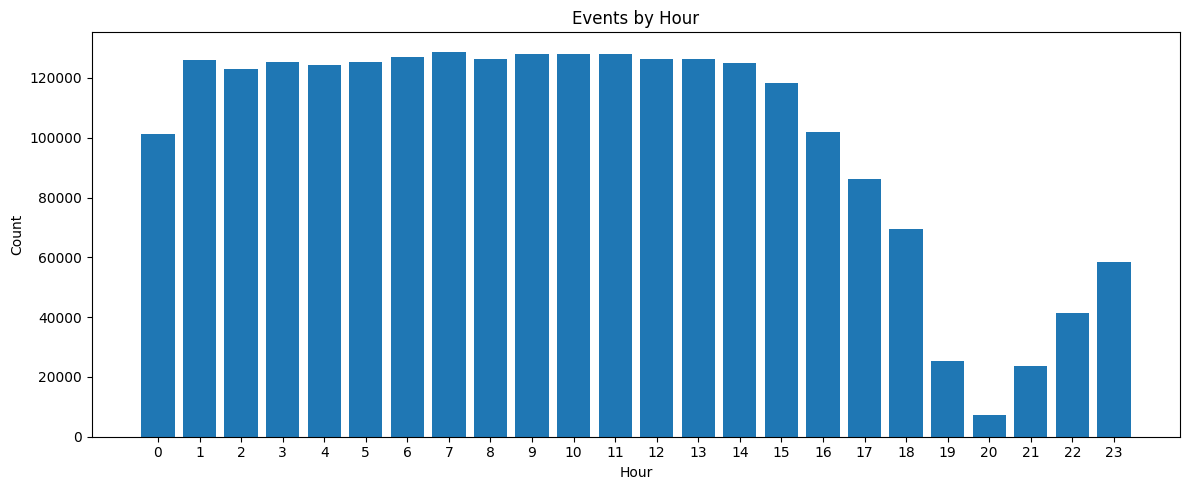

In [38]:
# hour별 건수 집계
df = (
    events[['hour']]
    .value_counts()                  # hour별 빈도
    .reset_index(name='count')       # count 컬럼 지정
    .sort_values(by='hour', key=lambda x: x.astype(int))          # 시간 오름차순 정렬
)

print(df)

# 막대그래프
plt.figure(figsize=(12, 5))
plt.bar(df['hour'], df['count'])
plt.xticks(df['hour'])               # 0~23 전체 시간이 보이도록
plt.xlabel("Hour")
plt.ylabel("Count")
plt.title("Events by Hour")
plt.tight_layout()
plt.show()

                  state  count
180                Acre    939
165               Aichi   1343
220               Akita     81
113             Alabama   4191
109             Alagoas   4498
..                  ...    ...
229           Yamanashi     13
77               Yunnan   9725
196  Zachodniopomorskie    498
5              Zhejiang  53288
21        Île-de-France  30275

[231 rows x 2 columns]


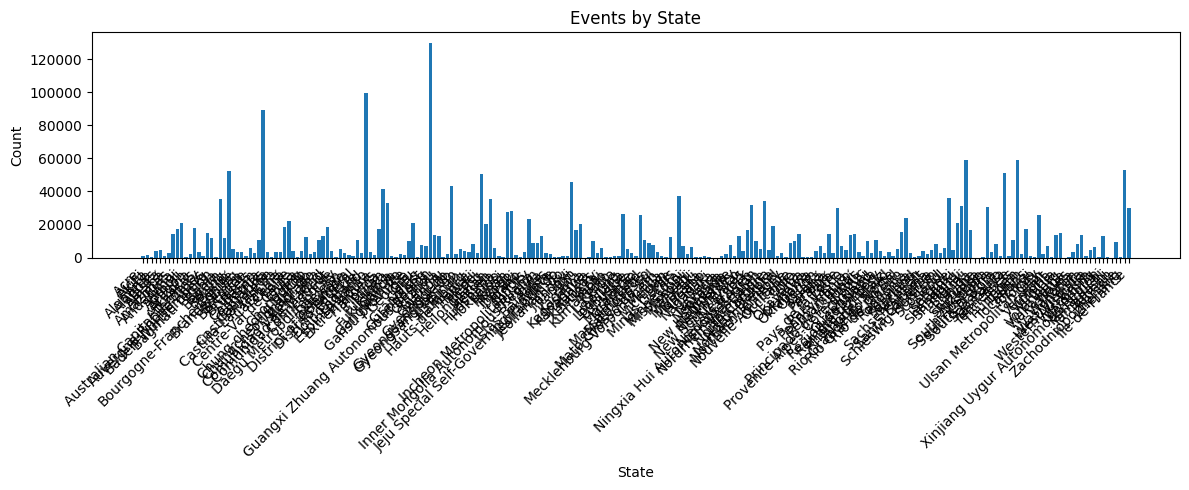

In [39]:
# state별 건수 집계
df = (
    events[['state']]
    .value_counts()               # state별 빈도수
    .reset_index(name='count')    # count 컬럼 이름 지정
    .sort_values(by='state')      # state 알파벳 순 정렬
)

print(df)

# 막대그래프 그리기
plt.figure(figsize=(12, 5))
plt.bar(df['state'], df['count'])
plt.xticks(rotation=45, ha='right')
plt.xlabel("State")
plt.ylabel("Count")
plt.title("Events by State")
plt.tight_layout()
plt.show()

    browser traffic_source   count
0    Chrome          Email  547261
1    Chrome        Adwords  366399
8    Chrome        Organic   61727
7    Chrome       Facebook  121437
6    Chrome        YouTube  121863
18  Firefox        Organic   23941
14  Firefox        YouTube   48054
12  Firefox       Facebook   49074
4   Firefox        Adwords  147067
2   Firefox          Email  219354
20       IE        YouTube   12262
19       IE       Facebook   12399
16       IE        Adwords   36166
9        IE          Email   54422
23       IE        Organic    6302
15    Other        Adwords   36565
10    Other          Email   54168
21    Other        YouTube   12038
22    Other       Facebook   11783
24    Other        Organic    5938
13   Safari        YouTube   48721
3    Safari          Email  216783
5    Safari        Adwords  144947
17   Safari        Organic   24151
11   Safari       Facebook   49141


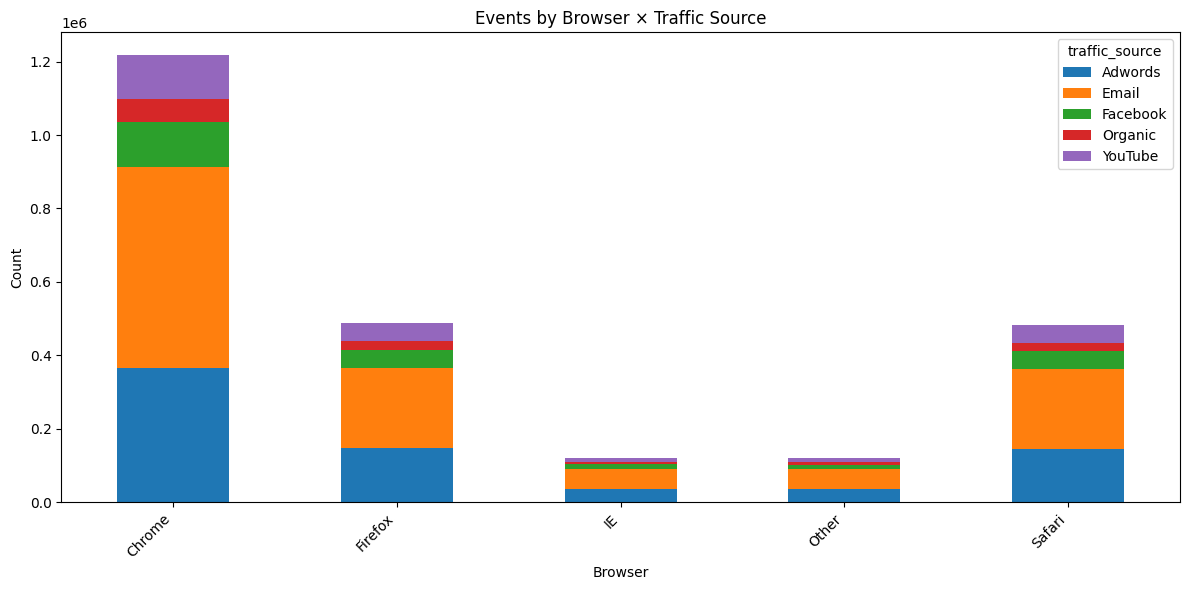

In [40]:
# browser별 건수 집계
df = (
    events[['browser', 'traffic_source']]
    .value_counts()                     # browser별 빈도
    .reset_index(name='count')          # count 컬럼 지정
    .sort_values(by='browser')          # browser 알파벳 순 정렬
)
print(df)

# 막대그래프
pivot_df = df.pivot(
    index='browser',
    columns='traffic_source',
    values='count'
).fillna(0)

pivot_df.plot(kind='bar', stacked=True, figsize=(12, 6))

plt.xticks(rotation=45, ha='right')
plt.xlabel("Browser")
plt.ylabel("Count")
plt.title("Events by Browser × Traffic Source")
plt.tight_layout()
plt.show()


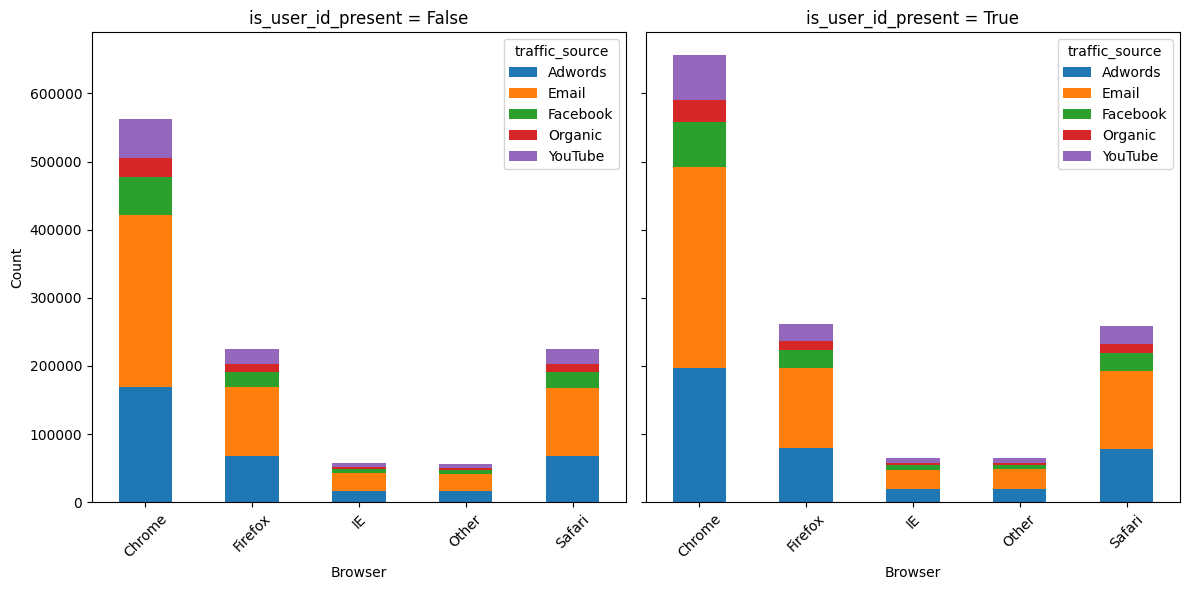

In [41]:
# 유저별 큰 차이 없네
# is_user_id_present × browser × traffic_source 집계
df = (
    events[['is_user_id_present', 'browser', 'traffic_source']]
    .value_counts()
    .reset_index(name='count')
)

# facet용 값 정렬
facet_values = sorted(df['is_user_id_present'].unique())

fig, axes = plt.subplots(
    1, len(facet_values),
    figsize=(6 * len(facet_values), 6),
    sharey=True
)

# 서브플롯이 1개인 경우에도 리스트처럼 다루기 위함
if len(facet_values) == 1:
    axes = [axes]

for ax, val in zip(axes, facet_values):
    sub = df[df['is_user_id_present'] == val].copy()
    sub = sub.sort_values(by='browser')

    pivot_df = (
        sub.pivot(
            index='browser',
            columns='traffic_source',
            values='count'
        )
        .fillna(0)
    )

    pivot_df.plot(
        kind='bar',
        stacked=True,
        ax=ax
    )

    ax.set_title(f"is_user_id_present = {val}")
    ax.set_xlabel("Browser")
    ax.set_ylabel("Count")
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


                             session_id                start_time  \
0  00000763-a855-4ad0-a95c-b160e749b272 2021-10-01 03:26:00+00:00   
1  0000364a-ce41-46f1-89d6-3f8704af77db 2022-08-22 10:46:40+00:00   
2  00004b15-f2d4-4687-b4c1-fc9ce336d39a 2022-06-11 01:28:00+00:00   
3  00004cf0-0d54-4347-8b0c-dccc700a2c96 2021-12-28 03:11:00+00:00   
4  00004e02-6372-47a6-aaf7-f231de654979 2023-12-15 10:28:16+00:00   

                   end_time        duration  duration_hour  duration_min  
0 2021-10-01 03:52:00+00:00 0 days 00:26:00       0.433333     26.000000  
1 2022-08-22 10:52:42+00:00 0 days 00:06:02       0.100556      6.033333  
2 2022-06-11 01:54:00+00:00 0 days 00:26:00       0.433333     26.000000  
3 2021-12-28 03:32:00+00:00 0 days 00:21:00       0.350000     21.000000  
4 2023-12-15 10:34:45+00:00 0 days 00:06:29       0.108056      6.483333  


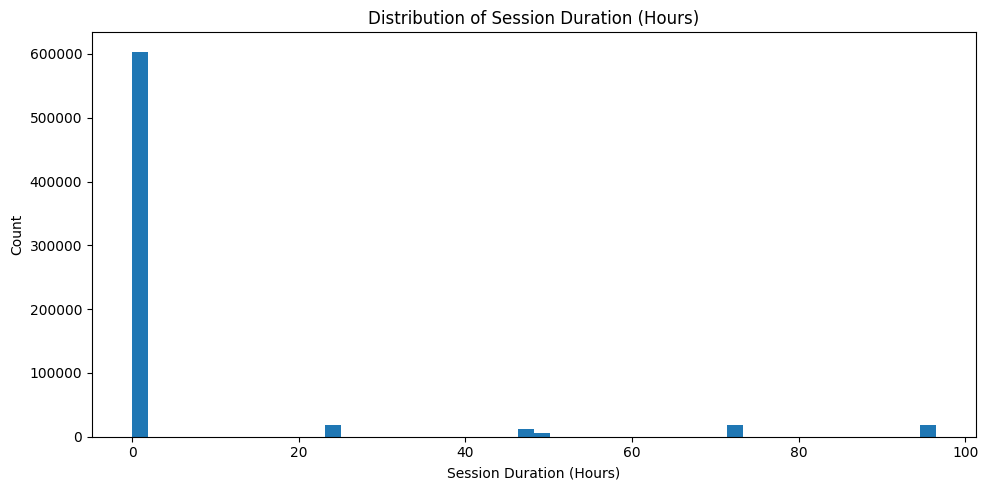

In [42]:
# created_at 컬럼이 datetime이 아니라면 먼저 변환
# events['created_at'] = pd.to_datetime(events['created_at'])

# session_id별 최소/최대 created_at 집계
session_time = (
    events.groupby('session_id')['created_at']
          .agg(start_time='min', end_time='max')
          .reset_index()
)

# 세션 지속시간 계산
session_time['duration'] = session_time['end_time'] - session_time['start_time']
session_time['duration_hour'] = session_time['duration'].dt.total_seconds() / 3600 # 시간 단위 변환
session_time['duration_min'] = session_time['duration'].dt.total_seconds() / 60 # 분 단위 변환
print(session_time.head())

# 원본 events에 merge
events = events.merge(
    session_time,
    on='session_id',
    how='left'
)

plt.figure(figsize=(10, 5))
plt.hist(session_time['duration_hour'], bins=50)
plt.xlabel("Session Duration (Hours)")
plt.ylabel("Count")
plt.title("Distribution of Session Duration (Hours)")
plt.tight_layout()
plt.show()


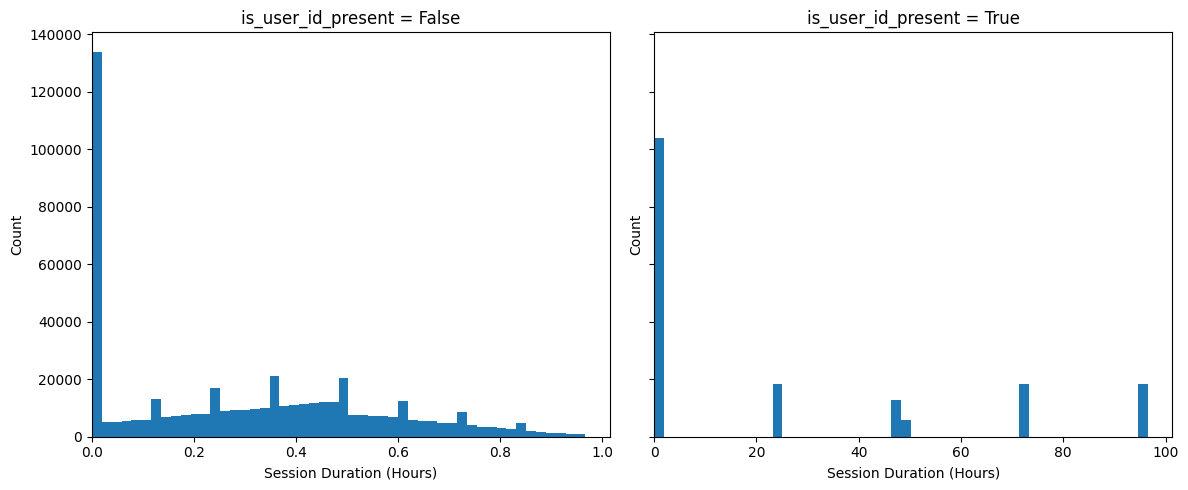

In [43]:
# 1) session_time에 is_user_id_present 붙이기
session_time = session_time.merge(
    events[['session_id', 'is_user_id_present']].drop_duplicates(),
    on='session_id',
    how='left'
)

# 2) 고유값 확인 (예: True / False 또는 0 / 1)
categories = sorted(session_time['is_user_id_present'].unique())

# 3) facet histogram
fig, axes = plt.subplots(1, len(categories), figsize=(12, 5), sharey=True)

if len(categories) == 1:
    axes = [axes]

for ax, cat in zip(axes, categories):
    subset = session_time[session_time['is_user_id_present'] == cat]
    
    ax.hist(subset['duration_hour'], bins=50)
    ax.set_title(f"is_user_id_present = {cat}")
    ax.set_xlabel("Session Duration (Hours)")
    ax.set_ylabel("Count")
    ax.set_xlim(left=0)  # 음수 방지

plt.tight_layout()
plt.show()


### 세부 패턴 및 관계 분석

### 분석 대상 확인

1안: 로그인 유저 대상 재구입 대상 예측

재구입 X인 경우, 34,996건
재구입 O인 경우, 45,048건


(구입 여부)
- train: 최초 구입 이후. 다음 시점(2번째)에 구입을 할 것인가?
- test: 다음 시점(2번째) 이후. 그 다음다음 시점(3번째)에 구입을 할 것인가

(상품 카테고리 예측)
- train: 첫번째 시점에서 구입한 다음. 다음 시점(2번째)에 구입을 할 것인가
- test: 두번째 시점에서 구입한 다음. 다음 시점(3번째)에 구입을 할 것인가

(재구입 시점 예측)
- train: 첫번째 시점에서 구입한 다음. 다음 시점(2번째)에 구입을 할 것인가
- test: 두번째 시점에서 구입한 다음. 다음 시점(3번째)에 구입을 할 것인가

In [51]:
# 유저 아이디 존재 테이블 생성
is_user_id_events = events[events['user_id'].notna()]

# 유저 아이디 미존재 테이블 생성
not_user_id_events = events[events['user_id'].isna()]

unique_session_count
1.0    174980
2.0    235486
3.0    207315
4.0    266220
5.0    170134
Name: count, dtype: int64
유저별 세션수가 1개인 경우: 174,980
유저별 세션수가 2개 이상인 경우: 1,131,312


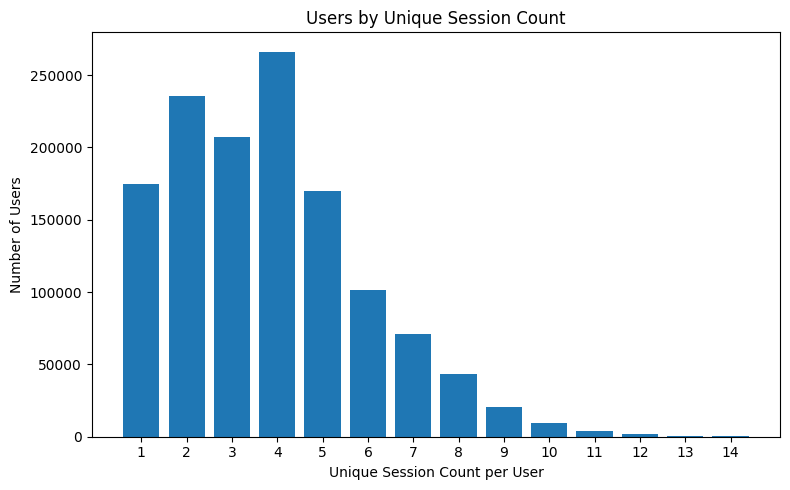

In [52]:
df = (
    is_user_id_events['unique_session_count']
    .value_counts()
    .sort_index()
)
print(df.head())
print(f"유저별 세션수가 1개인 경우: {df[df.index < 2].sum():,}")
print(f"유저별 세션수가 2개 이상인 경우: {df[df.index >= 2].sum():,}")

plt.figure(figsize=(8, 5))
plt.bar(df.index, df.values)
plt.xlabel("Unique Session Count per User")
plt.ylabel("Number of Users")
plt.title("Users by Unique Session Count")
plt.xticks(df.index)
plt.tight_layout()
plt.show()

    unique_session_count  avg_session_duration_hour
0                    1.0                   0.099516
1                    2.0                  24.187433
2                    3.0                  30.497112
3                    4.0                  33.574688
4                    5.0                  32.159344
5                    6.0                  35.577698
6                    7.0                  36.280647
7                    8.0                  39.752930
8                    9.0                  41.860098
9                   10.0                  44.467392
10                  11.0                  48.244609
11                  12.0                  47.090669
12                  13.0                  46.435897
13                  14.0                  46.565298


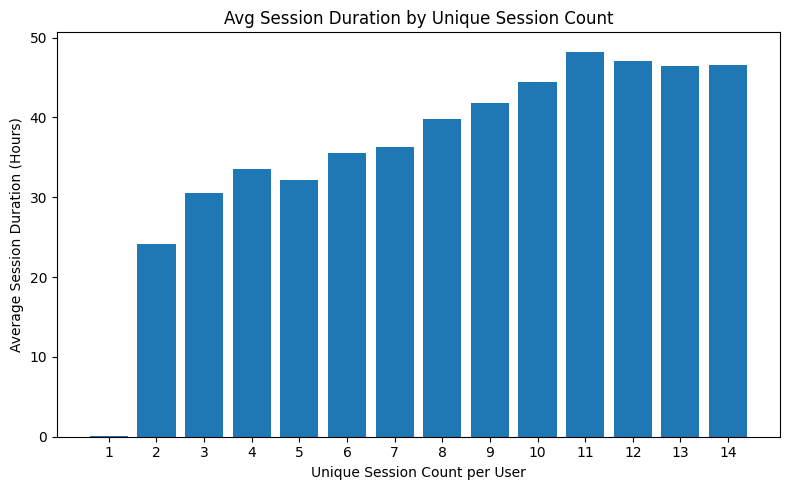

In [55]:
# 사용자별 세션 수(unique_session_count)가 많을수록 평균 세션 유지시간(duration_hour)이 어떻게 달라지는지
avg_duration = (
    is_user_id_events
    .drop_duplicates('session_id')  # 한 세션이 여러 row에 있으므로 중복 제거
    .groupby('unique_session_count')['duration_hour']
    .mean()
    .reset_index(name='avg_session_duration_hour')
)

print(avg_duration)

plt.figure(figsize=(8, 5))
plt.bar(avg_duration['unique_session_count'], avg_duration['avg_session_duration_hour'])
plt.xlabel("Unique Session Count per User")
plt.ylabel("Average Session Duration (Hours)")
plt.title("Avg Session Duration by Unique Session Count")
plt.xticks(avg_duration['unique_session_count'])
plt.tight_layout()
plt.show()

In [64]:
# 한 세션별 활동 수
is_user_id_events.groupby('session_id')['activity_count'].first().value_counts()

activity_count
5     87712
7     49734
13    25488
10    18825
Name: count, dtype: int64

In [65]:
is_user_id_events.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1306292 entries, 1251 to 2431962
Data columns (total 28 columns):
 #   Column                Non-Null Count    Dtype              
---  ------                --------------    -----              
 0   id                    1306292 non-null  string             
 1   user_id               1306292 non-null  string             
 2   sequence_number       1306292 non-null  string             
 3   session_id            1306292 non-null  string             
 4   created_at            1274791 non-null  datetime64[ns, UTC]
 5   ip_address            1306292 non-null  string             
 6   city                  1294116 non-null  string             
 7   state                 1306292 non-null  string             
 8   postal_code           1306292 non-null  string             
 9   browser               1306292 non-null  string             
 10  traffic_source        1306292 non-null  string             
 11  uri                   1306292 non-null 

In [67]:
# 세션별 유니크 값 확인
is_user_id_events#['session_id']

,id,user_id,sequence_number,session_id,created_at,ip_address,city,state,postal_code,browser,...,second,is_user_id_present,uri_splt,unique_session_count,activity_count,start_time,end_time,duration,duration_hour,duration_min
1251,458138,35092,3,e24636ad-3949-4174-bd09-4e2ae7a95aa3,2022-08-01 01:10:20+00:00,92.212.103.243,Sapporo,Hokkaido,003-0030,Chrome,...,20,True,/cart,5.0,7,2022-08-01 01:07:14+00:00,2022-08-02 01:20:26+00:00,1 days 00:13:12,24.220000,1453.200000
1252,444176,34028,6,b334f6d8-a1fd-42e9-90e4-8e8d2af7a663,2021-07-13 23:14:04+00:00,176.14.231.160,Sapporo,Hokkaido,007-0890,Safari,...,4,True,/cart,2.0,7,2021-07-13 23:10:34+00:00,2021-07-17 23:14:23+00:00,4 days 00:03:49,96.063611,5763.816667
1253,170896,13199,4,1df890d5-6783-4602-aa0a-e6668fed606e,2023-11-05 10:45:45+00:00,114.185.130.47,São Paulo,São Paulo,02220-000,Safari,...,45,True,/cart,1.0,5,2023-11-05 10:41:43+00:00,2023-11-05 10:47:29+00:00,0 days 00:05:46,0.096111,5.766667
1257,1147243,87818,3,e99fd570-3c66-4475-ab68-41c4a0da4bbc,2021-01-01 06:55:11+00:00,138.36.176.82,São Paulo,São Paulo,02675-031,Chrome,...,11,True,/cart,2.0,7,2021-01-01 06:51:23+00:00,2021-01-03 07:00:29+00:00,2 days 00:09:06,48.151667,2889.100000
1259,604658,46234,3,d566d275-4aea-4e90-be87-f119b4369f48,2023-12-22 12:38:20+00:00,163.100.101.188,São Paulo,São Paulo,02675-031,Safari,...,20,True,/cart,6.0,7,2023-12-22 12:35:01+00:00,2023-12-22 12:45:05+00:00,0 days 00:10:04,0.167778,10.066667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2431958,822590,62906,5,12ae51e7-76b3-4560-9335-3ea762eae60e,2022-04-07 01:55:02+00:00,52.92.60.25,St Helens,England,WA9,Firefox,...,2,True,/purchase,6.0,5,2022-04-07 01:49:39+00:00,2022-04-07 01:55:02+00:00,0 days 00:05:23,0.089722,5.383333
2431959,43178,3333,5,e472549e-273e-402e-ae5f-38ece25699c2,2023-09-26 10:25:28+00:00,97.78.106.249,Orrell,England,WN5,IE,...,28,True,/purchase,1.0,5,2023-09-26 10:16:36+00:00,2023-09-26 10:25:28+00:00,0 days 00:08:52,0.147778,8.866667
2431960,553230,42386,10,6a7ba027-2af2-46a3-ae05-294a264840cf,2023-07-31 15:11:10+00:00,147.252.137.75,Orrell,England,WN5,Chrome,...,10,True,/purchase,3.0,10,2023-07-30 14:55:14+00:00,2023-07-31 15:11:10+00:00,1 days 00:15:56,24.265556,1455.933333
2431961,1015190,77546,5,29e5960c-214b-456e-8c38-fe6eb8ff1ec8,2024-01-02 14:26:38+00:00,112.209.120.82,Wolverhampton,England,WV6,Chrome,...,38,True,/purchase,3.0,5,2024-01-02 14:21:32+00:00,2024-01-02 14:26:38+00:00,0 days 00:05:06,0.085000,5.100000


In [72]:
is_user_id_events['event_type'].value_counts()

event_type
cart          345607
department    345607
product       345607
purchase      181759
home           87712
Name: count, dtype: Int64

In [73]:
is_user_id_events[is_user_id_events['event_type'] == 'product']

,id,user_id,sequence_number,session_id,created_at,ip_address,city,state,postal_code,browser,...,second,is_user_id_present,uri_splt,unique_session_count,activity_count,start_time,end_time,duration,duration_hour,duration_min
14423,808412,61899,11,1daacb69-a4b6-4ef6-8686-bc62f86e87d5,2023-02-22 01:30:55+00:00,191.109.103.15,São Paulo,São Paulo,02220-000,Chrome,...,55,True,/product,4.0,13,2023-02-22 01:20:40+00:00,2023-02-25 01:33:38+00:00,3 days 00:12:58,72.216111,4332.966667
14425,535599,41024,8,aaf36cf1-331f-4ac5-afca-774dfccc52d6,2023-07-25 03:00:53+00:00,80.115.128.161,São Paulo,São Paulo,02675-031,Chrome,...,53,True,/product,4.0,13,2023-07-25 02:49:17+00:00,2023-07-29 03:07:30+00:00,4 days 00:18:13,96.303611,5778.216667
14426,515084,39381,2,e3acd62f-3350-4d9f-9bb5-75598b0ca241,2023-08-13 08:51:34+00:00,173.70.224.156,São Paulo,São Paulo,02675-031,IE,...,34,True,/product,2.0,7,2023-08-13 08:50:24+00:00,2023-08-15 08:58:17+00:00,2 days 00:07:53,48.131389,2887.883333
14428,481106,36813,3,588e0371-6e75-4cec-a60d-1765a4135e9c,2019-11-13 22:52:02+00:00,215.110.139.12,São Paulo,São Paulo,02675-031,Chrome,...,2,True,/product,1.0,5,2019-11-13 22:49:10+00:00,2019-11-13 22:55:23+00:00,0 days 00:06:13,0.103611,6.216667
14430,143867,11198,5,ac4d0e22-52b2-4d91-b31e-e849488a41d4,2023-10-16 21:22:26+00:00,75.253.156.227,São Paulo,São Paulo,02675-031,Chrome,...,26,True,/product,3.0,7,2023-10-16 21:17:00+00:00,2023-10-18 21:23:55+00:00,2 days 00:06:55,48.115278,2886.916667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2430019,553222,42386,2,6a7ba027-2af2-46a3-ae05-294a264840cf,2023-07-30 14:56:28+00:00,147.252.137.75,Orrell,England,WN5,Chrome,...,28,True,/product,3.0,10,2023-07-30 14:55:14+00:00,2023-07-31 15:11:10+00:00,1 days 00:15:56,24.265556,1455.933333
2430023,477860,36567,11,f62c56a7-55dc-40d1-b6d6-975a324e32a4,2020-08-03 07:40:15+00:00,88.93.212.188,Skelmersdale,England,WN8,Firefox,...,15,True,/product,4.0,13,2020-08-03 07:25:44+00:00,2020-08-03 07:40:42+00:00,0 days 00:14:58,0.249444,14.966667
2430024,268330,20509,3,31e606ea-d09e-4566-b4fc-eda2af193305,2020-10-17 04:36:07+00:00,61.57.66.112,Kempsey,England,WR5,Chrome,...,7,True,/product,2.0,5,2020-10-17 04:34:40+00:00,2020-10-17 04:38:59+00:00,0 days 00:04:19,0.071944,4.316667
2430027,498018,38025,3,fa0f14d2-e821-47bc-bb7c-d890535380f6,2022-07-02 12:14:06+00:00,186.9.28.101,Abbots Bromley,England,WS15,Other,...,6,True,/product,1.0,5,2022-07-02 12:09:01+00:00,2022-07-02 12:16:53+00:00,0 days 00:07:52,0.131111,7.866667


In [74]:
is_user_id_events['session_id'].nunique()

181759

## 3.1 inventory_items

In [ ]:
inventory_items.info(show_counts=True)

In [ ]:
inventory_items.describe(include='all')

In [ ]:
inventory_items

In [ ]:
print(inventory_items['id'].nunique())
print(inventory_items['product_id'].nunique())
print(inventory_items['product_sku'].nunique())

In [ ]:
inventory_items['product_distribution_center_id'].value_counts()

In [ ]:
print(inventory_items['created_at'].min())
print(inventory_items['created_at'].max())

In [ ]:
print(inventory_items.loc[inventory_items['sold_at'].notnull(), 'sold_at'].min())
print(inventory_items.loc[inventory_items['sold_at'].notnull(), 'sold_at'].max())

In [ ]:
# datetime 변환
inventory_items["created_at"] = pd.to_datetime(inventory_items["created_at"], utc=True, errors="coerce")
inventory_items["sold_at"] = pd.to_datetime(inventory_items["sold_at"], utc=True, errors="coerce")

In [ ]:
# 재고 머무른 시간(미판매의 경우 비교적 최근 시점_sold_at최대값을 기준으로

# datetime 변환
inventory_items["created_at"] = pd.to_datetime(inventory_items["created_at"], utc=True, errors="coerce")
inventory_items["sold_at"] = pd.to_datetime(inventory_items["sold_at"], utc=True, errors="coerce")

# 기준일: sold_at의 최대값
reference_date = inventory_items["sold_at"].max()

# 판매된 상품 → 판매까지 걸린 기간
inventory_items["days_to_sell"] = (inventory_items["sold_at"] - inventory_items["created_at"]).dt.total_seconds() / 86400

# 미판매 상품 → 현재까지 재고로 남아 있는 기간
inventory_items.loc[inventory_items["sold_at"].isna(), "days_to_sell"] = (
    (reference_date - inventory_items["created_at"]).dt.total_seconds() / 86400
)

inventory_items["days_to_sell"] = inventory_items["days_to_sell"].round(1)

In [ ]:
inventory_items["days_to_sell"].describe()

## 3.1 order_items

In [ ]:
order_items.info(show_counts=True)

In [ ]:
order_items.describe(include='all')

In [ ]:
order_items

In [ ]:
print(order_items['id'].nunique())
print(order_items['order_id'].nunique())
print(order_items['user_id'].nunique())
print(order_items['product_id'].nunique())
print(order_items['inventory_item_id'].nunique())

In [ ]:
order_summary = (
    order_items
    .groupby("order_id")
    .agg(
        product_count=("product_id", "nunique"),   # 상품 종류 수
        status_count=("status", "nunique")         # 상태 종류 수
    )
    .reset_index()
)

In [ ]:
order_summary['product_count'].value_counts()

In [ ]:
order_summary['status_count'].value_counts()

## 3.1 orders

In [ ]:
orders.info(show_counts=True)

In [ ]:
orders.describe(include='all')

In [ ]:
orders

## 3.1 products

In [ ]:
events.info(show_counts=True)

In [ ]:
events.describe(include='all')

In [ ]:
events

## 3.1 users

In [ ]:
events.info(show_counts=True)

In [ ]:
events.describe(include='all')

In [ ]:
events

## 3.1 events

In [ ]:
events.info(show_counts=True)

In [ ]:
events.describe(include='all')

In [ ]:
events